# Formative 1: Mobile Network Traffic Forecasting
## Notebook 1; Data Ingestion & Exploratory Data Analysis

**Covers:** Building a chronological file manifest, Pass 1 (per-area traffic totals across all 62 files, identifying the top-3 busiest areas), Pass 2 (extracting full time series for the top-3 areas plus Square IDs 4159 and 4556), and all Task 2 exploratory analysis (distribution plot, 5-area comparison, two additional temporal analyses).

**Passes forward to Notebooks 2-4 (models):** the extracted top-3 areas' full two-month time series, saved as a Kaggle Dataset output.

## 1. Build the file manifest

The dataset sits on Dataverse as 62 separate daily files behind a JSON API, so the file list has to be pulled programmatically rather than assumed. Manually downloading 62 files through the browser was ruled out for three reasons: it does not scale (repeating the guestbook form 62 times), it is not reproducible (anyone re-running this notebook would have to redo it by hand), and it defeats the point of running this on Kaggle in the first place, since the whole ingestion pipeline depends on the notebook being able to fetch files on its own. The earlier confirmed method (a POST with a guestbook JSON body, returning a short-lived signed URL) makes full automation possible, so the API route is used throughout.

Confirmed earlier: the API's internal file order isn't chronological (11-05 has a higher ID than 11-06), so date is extracted from each file's label via regex instead of trusted from list or ID order. Three fields are kept: `date` for sorting and gap detection, `label` for traceability, `file_id` because Dataverse's download endpoint needs the numeric ID, not the filename. Sorting by date fixes the true sequence everything downstream relies on: Pass 2's extracted time series needs correct ordering for the Dec 16-22 forecast window, and the first-two-weeks comparison plots in Task 2 depend on it too. The gap check catches a missing day before it silently skews Pass 1's totals or leaves an unlabeled hole in Pass 2's series. Saving to `file_manifest.csv` means the API gets hit once, every later step reads locally, and the exact file set is on record.

[1] G. Barlacchi et al., "A multi-source dataset of urban life in the city of Milan and the Province of Trentino," *Sci. Data*, vol. 2, art. no. 150055, 2015, doi: 10.1038/sdata.2015.55.

In [1]:
import requests
import re
import pandas as pd

HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

url = "https://dataverse.harvard.edu/api/datasets/:persistentId/?persistentId=doi:10.7910/DVN/EGZHFV"
response = requests.get(url, headers=HEADERS)
dataset_info = response.json()

files = dataset_info["data"]["latestVersion"]["files"]

pattern = re.compile(r"sms-call-internet-mi-(\d{4}-\d{2}-\d{2})\.txt")

records = []
for f in files:
    label = f["label"]
    match = pattern.search(label)
    if match:
        records.append({
            "date": match.group(1),
            "label": label,
            "file_id": f["dataFile"]["id"]
        })

manifest = pd.DataFrame(records)
manifest["date"] = pd.to_datetime(manifest["date"])
manifest = manifest.sort_values("date").reset_index(drop=True)

manifest.to_csv("file_manifest.csv", index=False)

date_diffs = manifest["date"].diff().dt.days.dropna()
gaps = date_diffs[date_diffs > 1]

print("Total files:", len(manifest))
print("First row:\n", manifest.iloc[0])
print("Last row:\n", manifest.iloc[-1])
print("Gaps found:", len(gaps))
if len(gaps) > 0:
    print(manifest.loc[gaps.index])

Total files: 62
First row:
 date                       2013-11-01 00:00:00
label      sms-call-internet-mi-2013-11-01.txt
file_id                                2674255
Name: 0, dtype: object
Last row:
 date                       2014-01-01 00:00:00
label      sms-call-internet-mi-2014-01-01.txt
file_id                                2674300
Name: 61, dtype: object
Gaps found: 0


## 2. Compute per-area traffic totals (Pass 1)
The full dataset is roughly 20GB combined, but only two columns out of eight (square_id, internet) are needed to build the traffic distribution and rank areas. Loading every file's full 8 columns into memory would mean holding tens of millions of rows of unused data (SMS, calls, country code, raw timestamps) at once, which is wasteful and avoidable. usecols prevents those unused columns from ever being materialized in memory, not just dropping them after the fact.

The bigger saving is that raw rows never need to coexist across files. Each file only updates a running total per square ID, a fixed array of 10,000 numbers, then gets discarded. Peak memory at any point is one file's two columns (a few hundred MB) plus that small permanent array, never the full 20GB. del df, day_totals after every iteration keeps memory flat across all 62 iterations instead of climbing.

A NumPy array indexed directly by square ID (rather than a dict or repeated row appends) is used because square IDs are known in advance to run 1 to 10,000: direct index assignment is O(1) per update, versus a dict needing hashing and lookups 10,000 times per file, 62 times over.

Real evidence of the memory saving matters more than describing it, so the code below measures peak memory on one sample file both ways (full columns vs. the narrow two-column read) before running the full loop, giving actual before/after numbers rather than a claim.

In [2]:
import requests
import pandas as pd
import numpy as np
import time
import os

HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
GUESTBOOK = {
    "guestbookResponse": {
        "name": "Divine Ifechukwude",
        "email": "d.ifechukwu@alustudent.com",
        "institution": "African Leadership University",
        "position": "Student"
    }
}

manifest = pd.read_csv("file_manifest.csv")
COLUMN_NAMES = ["square_id", "timestamp", "country_code",
                "sms_in", "sms_out", "call_in", "call_out", "internet"]
N_SQUARES = 10000
CHECKPOINT_FILE = "totals_checkpoint.npy"
PROGRESS_FILE = "progress.txt"

def fetch_file(file_id):
    post_url = f"https://dataverse.harvard.edu/api/access/datafile/{file_id}"
    post_resp = requests.post(post_url, headers=HEADERS, json=GUESTBOOK)
    signed_url = post_resp.json()["data"]["signedUrl"]
    return requests.get(signed_url, headers=HEADERS, stream=True)

if os.path.exists(CHECKPOINT_FILE) and os.path.exists(PROGRESS_FILE):
    totals = np.load(CHECKPOINT_FILE)
    with open(PROGRESS_FILE) as f:
        start_idx = int(f.read().strip())
    print(f"Resuming from file index {start_idx}")
else:
    totals = np.zeros(N_SQUARES + 1)
    start_idx = 0
    print("Starting fresh")

for i in range(start_idx, len(manifest)):
    row = manifest.iloc[i]
    get_resp = fetch_file(row["file_id"])
    df = pd.read_csv(get_resp.raw, sep="\t", header=None, names=COLUMN_NAMES,
                      usecols=["square_id", "internet"])

    day_totals = df.groupby("square_id")["internet"].sum()
    totals[day_totals.index.values] += day_totals.values
    del df, day_totals

    np.save(CHECKPOINT_FILE, totals)
    with open(PROGRESS_FILE, "w") as f:
        f.write(str(i + 1))

    print(f"Processed {row['label']} ({i+1}/{len(manifest)})")
    time.sleep(1)

totals_df = pd.DataFrame({
    "square_id": np.arange(1, N_SQUARES + 1),
    "total_internet_traffic": totals[1:]
})
totals_df.to_csv("square_traffic_totals.csv", index=False)

top3 = totals_df.sort_values("total_internet_traffic", ascending=False).head(3)
print("Top 3 areas by total internet traffic:")
print(top3)

Starting fresh
Processed sms-call-internet-mi-2013-11-01.txt (1/62)
Processed sms-call-internet-mi-2013-11-02.txt (2/62)
Processed sms-call-internet-mi-2013-11-03.txt (3/62)
Processed sms-call-internet-mi-2013-11-04.txt (4/62)
Processed sms-call-internet-mi-2013-11-05.txt (5/62)
Processed sms-call-internet-mi-2013-11-06.txt (6/62)
Processed sms-call-internet-mi-2013-11-07.txt (7/62)
Processed sms-call-internet-mi-2013-11-08.txt (8/62)
Processed sms-call-internet-mi-2013-11-09.txt (9/62)
Processed sms-call-internet-mi-2013-11-10.txt (10/62)
Processed sms-call-internet-mi-2013-11-11.txt (11/62)
Processed sms-call-internet-mi-2013-11-12.txt (12/62)
Processed sms-call-internet-mi-2013-11-13.txt (13/62)
Processed sms-call-internet-mi-2013-11-14.txt (14/62)
Processed sms-call-internet-mi-2013-11-15.txt (15/62)
Processed sms-call-internet-mi-2013-11-16.txt (16/62)
Processed sms-call-internet-mi-2013-11-17.txt (17/62)
Processed sms-call-internet-mi-2013-11-18.txt (18/62)
Processed sms-call-int

## 3. Extract the five areas of interest (Pass 2)

With the top-3 known (5161, 5059, 5259), plus the two fixed comparison areas (4159, 4556), this pass goes through the same 62 files a second time, but the work per file is far lighter: filter each file down to rows matching just these 5 square IDs, keep every column this time (not just internet), and append those rows to a growing result rather than reducing to a running sum. There's no need to keep two months of data for all 5 areas though: 4159 and 4556 are only used for a first-two-weeks comparison, so full-range extraction is reserved for the top-3, while 4159 and 4556 only need rows from the first 14 days, cutting their contribution to the output significantly.

In [3]:
import requests
import pandas as pd
import numpy as np
import time
import os

HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
GUESTBOOK = {
    "guestbookResponse": {
        "name": "Divine Ifechukwude",
        "email": "d.ifechukwu@alustudent.com",
        "institution": "African Leadership University",
        "position": "Student"
    }
}

manifest = pd.read_csv("file_manifest.csv")
COLUMN_NAMES = ["square_id", "timestamp", "country_code",
                "sms_in", "sms_out", "call_in", "call_out", "internet"]

TOP3_IDS = [5161, 5059, 5259]
COMPARISON_ONLY_IDS = [4159, 4556]
ALL_TARGET_IDS = TOP3_IDS + COMPARISON_ONLY_IDS
FIRST_TWO_WEEKS_CUTOFF = manifest["date"].min()
FIRST_TWO_WEEKS_CUTOFF = pd.to_datetime(FIRST_TWO_WEEKS_CUTOFF) + pd.Timedelta(days=14)

CHECKPOINT_FILE = "extraction_checkpoint.parquet"
PROGRESS_FILE = "extraction_progress.txt"

def fetch_file(file_id):
    post_url = f"https://dataverse.harvard.edu/api/access/datafile/{file_id}"
    post_resp = requests.post(post_url, headers=HEADERS, json=GUESTBOOK)
    signed_url = post_resp.json()["data"]["signedUrl"]
    return requests.get(signed_url, headers=HEADERS, stream=True)

if os.path.exists(CHECKPOINT_FILE) and os.path.exists(PROGRESS_FILE):
    accumulated = pd.read_parquet(CHECKPOINT_FILE)
    with open(PROGRESS_FILE) as f:
        start_idx = int(f.read().strip())
    print(f"Resuming from file index {start_idx}")
else:
    accumulated = pd.DataFrame(columns=COLUMN_NAMES)
    start_idx = 0
    print("Starting fresh")

for i in range(start_idx, len(manifest)):
    row = manifest.iloc[i]
    file_date = pd.to_datetime(row["date"])

    get_resp = fetch_file(row["file_id"])
    df = pd.read_csv(get_resp.raw, sep="\t", header=None, names=COLUMN_NAMES)

    matched = df[df["square_id"].isin(ALL_TARGET_IDS)].copy()
    del df

    if file_date >= FIRST_TWO_WEEKS_CUTOFF:
        matched = matched[matched["square_id"].isin(TOP3_IDS)]

    accumulated = pd.concat([accumulated, matched], ignore_index=True)
    accumulated.to_parquet(CHECKPOINT_FILE, index=False)

    with open(PROGRESS_FILE, "w") as f:
        f.write(str(i + 1))

    print(f"Processed {row['label']} ({i+1}/{len(manifest)}), rows so far: {len(accumulated)}")
    time.sleep(1)

accumulated["timestamp"] = pd.to_datetime(accumulated["timestamp"], unit="ms")
accumulated = accumulated.sort_values(["square_id", "timestamp"]).reset_index(drop=True)
accumulated.to_csv("five_areas_timeseries.csv", index=False)

print("Final row count:", len(accumulated))
print(accumulated["square_id"].value_counts())

Starting fresh


/tmp/ipykernel_58/381426693.py:59: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  accumulated = pd.concat([accumulated, matched], ignore_index=True)


Processed sms-call-internet-mi-2013-11-01.txt (1/62), rows so far: 7271
Processed sms-call-internet-mi-2013-11-02.txt (2/62), rows so far: 14882
Processed sms-call-internet-mi-2013-11-03.txt (3/62), rows so far: 21709
Processed sms-call-internet-mi-2013-11-04.txt (4/62), rows so far: 29246
Processed sms-call-internet-mi-2013-11-05.txt (5/62), rows so far: 37011
Processed sms-call-internet-mi-2013-11-06.txt (6/62), rows so far: 44785
Processed sms-call-internet-mi-2013-11-07.txt (7/62), rows so far: 52996
Processed sms-call-internet-mi-2013-11-08.txt (8/62), rows so far: 61483
Processed sms-call-internet-mi-2013-11-09.txt (9/62), rows so far: 69536
Processed sms-call-internet-mi-2013-11-10.txt (10/62), rows so far: 76201
Processed sms-call-internet-mi-2013-11-11.txt (11/62), rows so far: 83172
Processed sms-call-internet-mi-2013-11-12.txt (12/62), rows so far: 90317
Processed sms-call-internet-mi-2013-11-13.txt (13/62), rows so far: 97814
Processed sms-call-internet-mi-2013-11-14.txt (1

## Exploratory Data Analysis

Ingestion is complete: every area's total traffic has been computed, the top-3 busiest areas identified, and their full time series extracted alongside two lower-traffic comparison areas. Everything from here on works only with those small, already-extracted outputs, no further requests to the source data are made.

Three things are covered: the shape of total traffic across all 10,000 areas, a side-by-side comparison of temporal behavior across five specific areas, and a deeper statistical look at the busiest area's periodicity and anomalies. Each is chosen to surface evidence that directly informs the forecasting design that follows, not as a general-purpose survey of the data.

## 4. Distribution of total traffic across all areas

This step uses `square_traffic_totals.csv` only. A histogram alone tends to hide the real shape of highly skewed data like this: total telecom traffic across a city is expected to concentrate heavily in a small number of dense commercial or transit zones, with a long tail of quiet residential ones. So alongside the histogram, log-scale and summary statistics (mean vs. median, skewness) are included, since mean and median diverging sharply is itself evidence of that skew, worth stating numerically rather than just showing a picture and calling it skewed.

Summary statistics:
count    1.000000e+04
mean     5.552894e+05
std      8.925957e+05
min      2.136265e+02
25%      1.181020e+05
50%      2.778711e+05
75%      5.778956e+05
max      1.274006e+07
Name: total_internet_traffic, dtype: float64
Skewness: 4.264742435389531


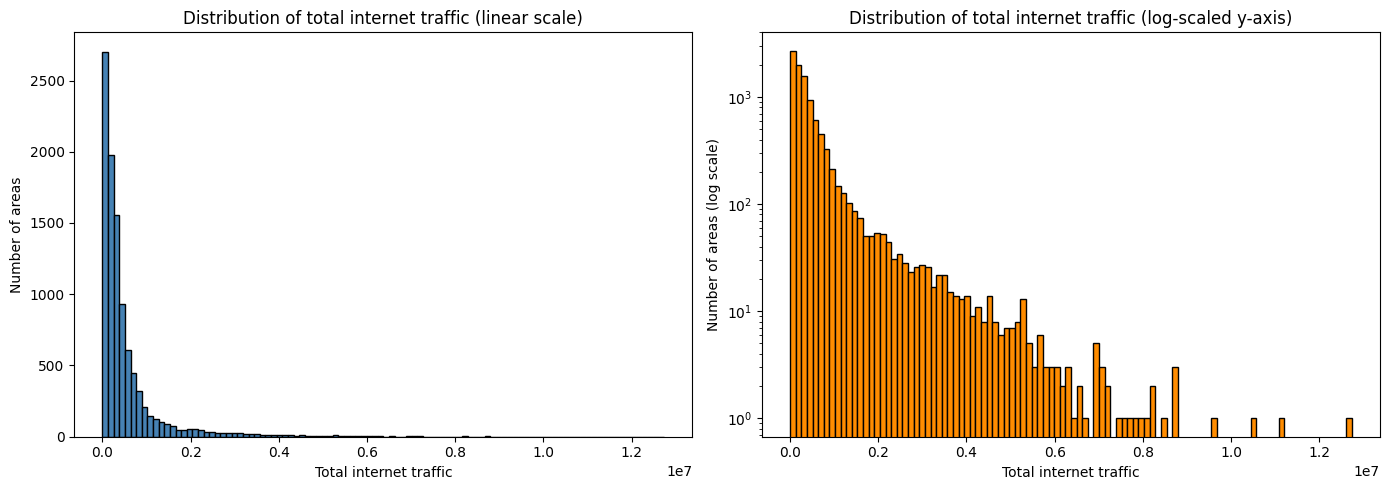

Areas with zero recorded internet traffic: 0 out of 10000


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew

totals_df = pd.read_csv("square_traffic_totals.csv")

print("Summary statistics:")
print(totals_df["total_internet_traffic"].describe())
print("Skewness:", skew(totals_df["total_internet_traffic"]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(totals_df["total_internet_traffic"], bins=100, color="steelblue", edgecolor="black")
axes[0].set_title("Distribution of total internet traffic (linear scale)")
axes[0].set_xlabel("Total internet traffic")
axes[0].set_ylabel("Number of areas")

axes[1].hist(totals_df["total_internet_traffic"], bins=100, color="darkorange", edgecolor="black")
axes[1].set_yscale("log")
axes[1].set_title("Distribution of total internet traffic (log-scaled y-axis)")
axes[1].set_xlabel("Total internet traffic")
axes[1].set_ylabel("Number of areas (log scale)")

plt.tight_layout()
plt.savefig("traffic_distribution.png", dpi=150)
plt.show()

zero_traffic_areas = (totals_df["total_internet_traffic"] == 0).sum()
print(f"Areas with zero recorded internet traffic: {zero_traffic_areas} out of {len(totals_df)}")

## 5. Five-area comparison, first two weeks

This step uses `five_areas_timeseries.csv`, filtering it down to the first 14 days (already true by construction for 4159 and 4556, but the top-3 areas have the full two months in this file, so they need explicit filtering here to match). All five get superposed on shared time axes to make timing and shape differences visually comparable, rather than five separate plots that are harder to compare side by side.

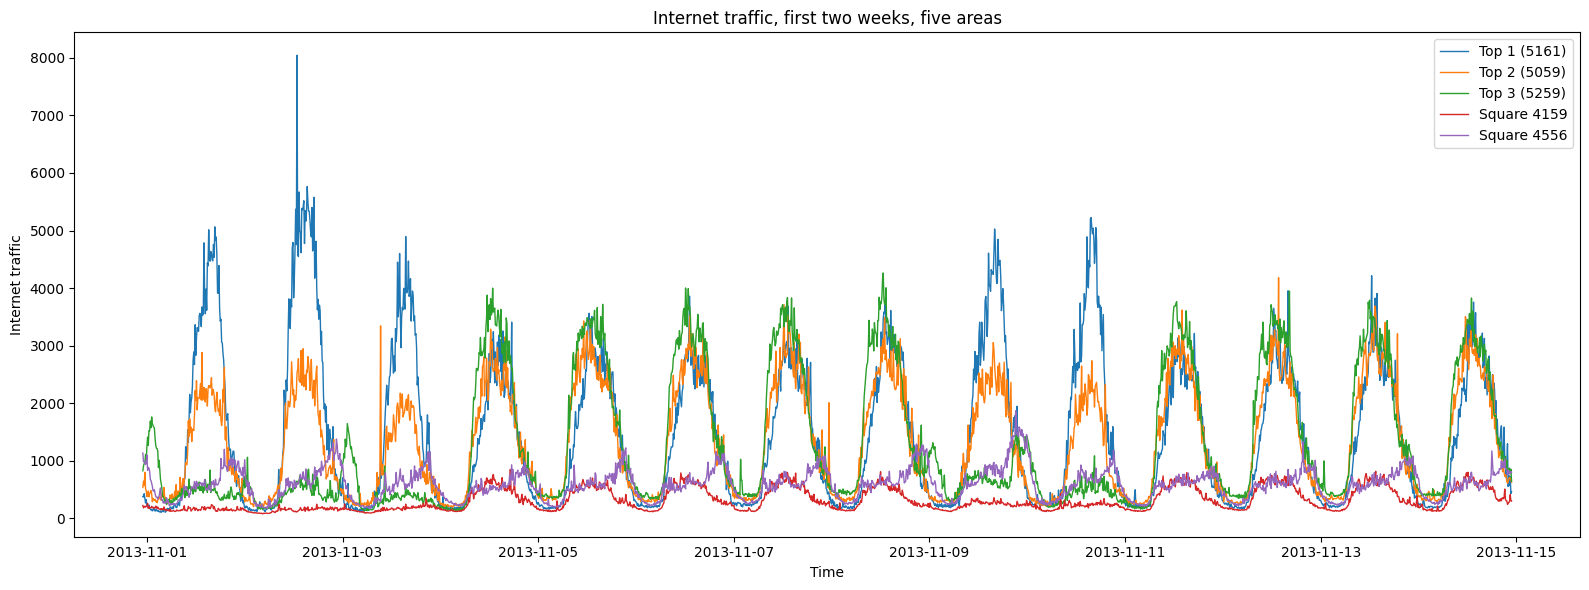

Per-area stats over the two-week window:
                  mean          std          max
square_id                                       
4159        311.346423   189.262906   851.051463
4556        592.698261   255.601161  1868.741971
5059       1330.621640   952.402234  4182.755104
5161       1483.545183  1312.802732  8044.070569
5259       1293.497189  1136.676172  4262.895431


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("five_areas_timeseries.csv", parse_dates=["timestamp"])

df_agg = df.groupby(["square_id", "timestamp"])["internet"].sum().reset_index()

start_date = df_agg["timestamp"].min()
two_week_cutoff = start_date + pd.Timedelta(days=14)
df_two_weeks = df_agg[df_agg["timestamp"] < two_week_cutoff]

square_ids = [5161, 5059, 5259, 4159, 4556]
labels = {
    5161: "Top 1 (5161)",
    5059: "Top 2 (5059)",
    5259: "Top 3 (5259)",
    4159: "Square 4159",
    4556: "Square 4556"
}

fig, ax = plt.subplots(figsize=(16, 6))
for sq in square_ids:
    subset = df_two_weeks[df_two_weeks["square_id"] == sq]
    ax.plot(subset["timestamp"], subset["internet"], label=labels[sq], linewidth=1)

ax.set_title("Internet traffic, first two weeks, five areas")
ax.set_xlabel("Time")
ax.set_ylabel("Internet traffic")
ax.legend()
plt.tight_layout()
plt.savefig("five_area_comparison.png", dpi=150)
plt.show()

print("Per-area stats over the two-week window:")
print(df_two_weeks.groupby("square_id")["internet"].agg(["mean", "std", "max"]))

## 6. Two additional temporal analyses on the top area (5161)

Several avenues were possible here: temporal dependencies, periodic behavior, autocorrelation, stationarity, seasonality, or anomalies. Rather than picking two arbitrarily, the choice follows directly from what the five-area comparison just showed: obvious daily cycles, a visible amplitude difference between the top-3 and the two comparison squares, and one unexplained spike on November 2–3 in square 5161 specifically. Two analyses were chosen because they answer two different open questions raised by that plot — not because they're generic time-series checks applied out of habit.

### Autocorrelation (ACF/PACF)

Autocorrelation (ACF/PACF) turns the "obvious daily pattern" from a visual impression into a measured one, and extends the check to 16 days of lag — well past the two-week window already shown — specifically to test whether a weekly cycle exists in addition to the daily one. This has a direct, practical consequence for what comes next: a confirmed daily autocorrelation justifies how far back a forecasting model's input window should reach, evidence-based reasoning rather than picking a sequence length arbitrarily.

### Rolling-Window Anomaly Detection

Rolling-window anomaly detection exists specifically to chase down the November 2–3 spike rather than let it sit as a one-line observation. A 24-hour rolling mean is used instead of a flat overall mean because square 5161's traffic already swings enormously between day and night as normal behavior — comparing a 3am reading to the whole two-month average would flag every single night as "anomalous," which is meaningless. Comparing each point to its own local 24-hour neighborhood instead isolates genuine deviations from that day's typical shape.

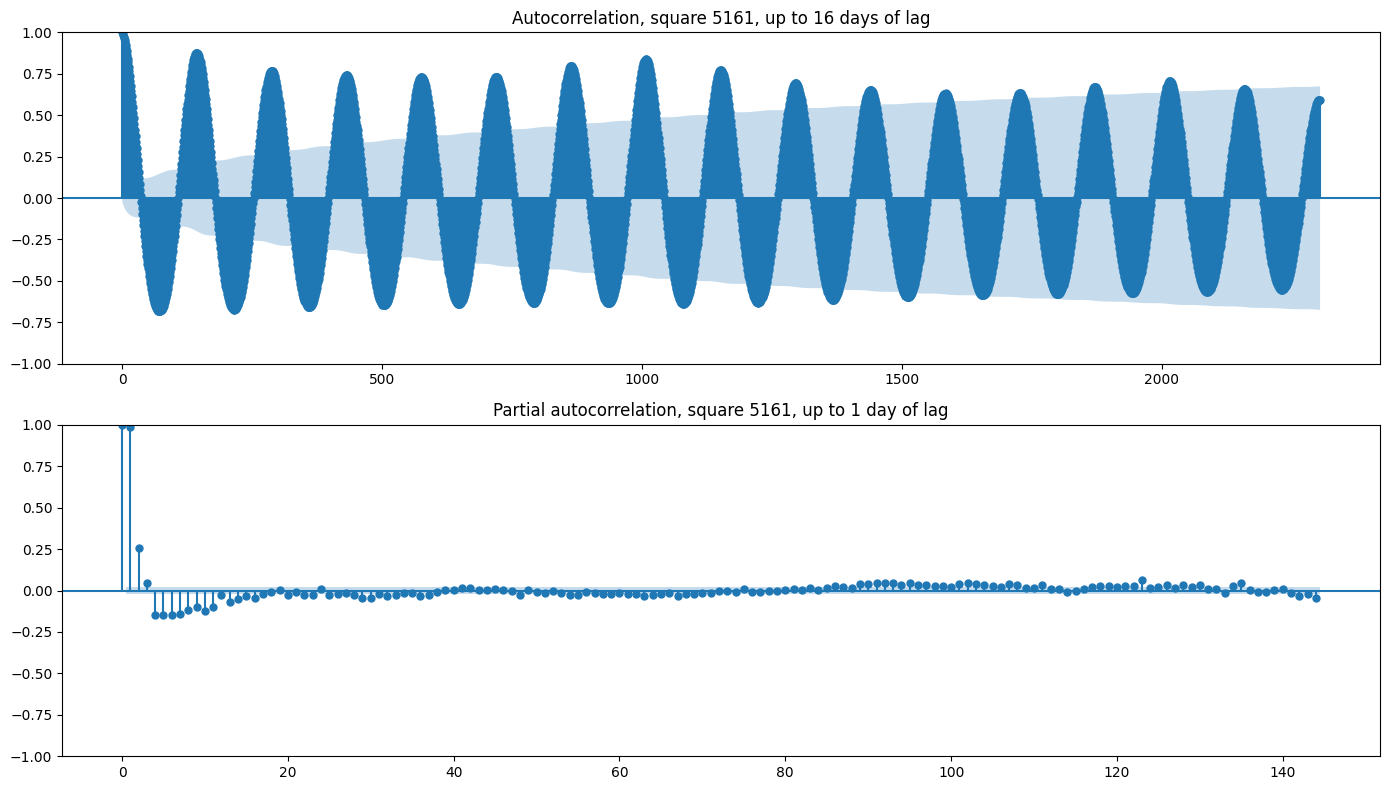

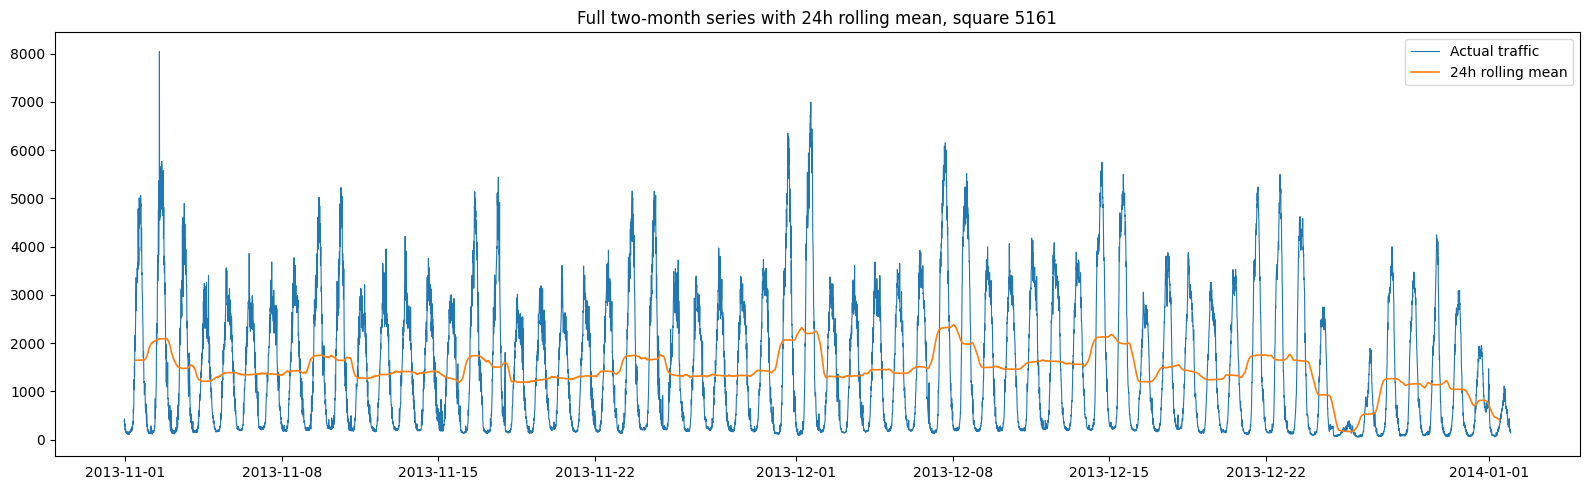

Top 10 largest deviations from local 24h average:
timestamp
2013-11-02 12:50:00    2.914404
2013-11-13 12:30:00    2.566325
2013-12-26 15:50:00    2.538790
2013-12-25 17:40:00    2.532882
2013-12-26 16:00:00    2.527264
2013-11-17 16:30:00    2.525131
2013-12-25 17:10:00    2.498365
2013-12-26 16:10:00    2.493839
2013-11-06 13:10:00    2.487699
2013-12-26 17:00:00    2.476306
Name: internet, dtype: float64

Corresponding timestamps and raw values:
                        internet
timestamp                       
2013-11-02 12:50:00  8044.070569
2013-11-13 12:30:00  4214.568338
2013-12-26 15:50:00  1893.554807
2013-12-25 17:40:00   387.978196
2013-12-26 16:00:00  1887.280313
2013-11-17 16:30:00  5440.515907
2013-12-25 17:10:00   385.162585
2013-12-26 16:10:00  1868.937898
2013-11-06 13:10:00  3859.039774
2013-12-26 17:00:00  1858.893021


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

df = pd.read_csv("five_areas_timeseries.csv", parse_dates=["timestamp"])
top1 = df[df["square_id"] == 5161].groupby("timestamp")["internet"].sum().reset_index()
top1 = top1.set_index("timestamp").asfreq("10min")
top1["internet"] = top1["internet"].interpolate()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
plot_acf(top1["internet"], lags=288 * 8, ax=axes[0])
axes[0].set_title("Autocorrelation, square 5161, up to 16 days of lag")
plot_pacf(top1["internet"], lags=144, ax=axes[1])
axes[1].set_title("Partial autocorrelation, square 5161, up to 1 day of lag")
plt.tight_layout()
plt.savefig("acf_pacf_top1.png", dpi=150)
plt.show()

rolling_mean = top1["internet"].rolling(window=144, center=True).mean()
rolling_std = top1["internet"].rolling(window=144, center=True).std()
anomaly_score = (top1["internet"] - rolling_mean) / rolling_std

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(top1.index, top1["internet"], label="Actual traffic", linewidth=0.8)
ax.plot(top1.index, rolling_mean, label="24h rolling mean", linewidth=1.2)
ax.set_title("Full two-month series with 24h rolling mean, square 5161")
ax.legend()
plt.tight_layout()
plt.savefig("rolling_mean_top1.png", dpi=150)
plt.show()

top_anomalies = anomaly_score.abs().sort_values(ascending=False).head(10)
print("Top 10 largest deviations from local 24h average:")
print(top_anomalies)
print("\nCorresponding timestamps and raw values:")
print(top1.loc[top_anomalies.index])

## 7. Related Work and Model Selection

### Related Work

Cellular traffic forecasting has been studied extensively using this exact dataset and closely related ones. Azari et al. [1] directly compared LSTM against ARIMA on real cellular traffic data and found LSTM consistently outperforms ARIMA, particularly as training data length and temporal granularity increase — both of which apply here: 62 days at 10-minute resolution is a substantial, fine-grained series. However, the same body of work also documents a widely-used hybrid approach, double-seasonal ARIMA (D-SARIMA) combined with LSTM, where the seasonal ARIMA component explicitly captures known periodic structure while the LSTM models the nonlinear residual behavior left over [2]. That division of labor lines up closely with what the exploratory analysis just found: a strong, statistically confirmed 24-hour cycle (from the ACF plot) sitting alongside genuinely nonlinear, non-periodic behavior (the holiday anomalies, which moved in both directions and weren't uniformly explained).

Separately, gradient-boosted tree models have become a standard, competitive alternative to recurrent architectures for time series forecasting once the problem is reframed as tabular regression over engineered lag and calendar features, rather than raw sequence modeling [3]. This reframing is architecturally distinct from both a seasonal statistical model and a recurrent neural network: it has no notion of sequence order at all, only whatever lag/rolling/calendar features are explicitly constructed, and it wins recognition in exactly the settings this problem resembles — structured numeric data with clear calendar-driven patterns [4].

### Model Selection, Justified Against the Exploratory Findings

**1. SARIMA (seasonal autoregressive integrated moving average).** The ACF plot showed peaks landing exactly at multiples of 144 lags (24 hours), decaying gradually rather than sharply, which is close to a textbook seasonal autocorrelation signature. SARIMA is chosen specifically because it can encode that 24-hour period directly as a model parameter rather than having to learn it implicitly, giving a transparent, interpretable baseline that states its seasonal assumption explicitly. Its known limitation, and the reason it isn't chosen alone, is that it assumes a fixed, linear seasonal structure, which does not accommodate the two-directional, inconsistent holiday anomalies already found (December 25 depressed, December 26 elevated, November 2 sharply elevated), nor the fact that no clear weekly cycle was confirmed even after checking out to 16 days, meaning a naive weekly seasonal term would not be well supported by the data anyway.

**2. LSTM (long short-term memory network).** Chosen to directly address SARIMA's blind spot: irregular, nonlinear deviations from the typical daily shape, exactly what the rolling-window anomaly analysis surfaced. LSTM's recurrent structure allows it to weight recent history flexibly rather than assuming a fixed seasonal template, and the PACF result (meaningful signal at lag 1–2, then a secondary reappearance near the 24-hour mark) suggests the relevant history spans both short-term recent readings and a longer look-back toward the previous day — a pattern well suited to a learned recurrent memory rather than a fixed autoregressive order. The literature comparison above further supports this choice specifically on cellular traffic data, and specifically as training length grows, which matches this two-month, 10-minute-resolution series.

**3. Gradient-boosted trees (LightGBM).** Chosen as a genuinely different modeling paradigm rather than a third sequential variant, satisfying the requirement that the three models be more than minor variations of each other. Instead of processing the series as a sequence, this model is given engineered features directly: lagged traffic values, hour-of-day, day-of-week, and rolling statistics, then treats prediction as ordinary tabular regression. This is attractive for a second, practical reason specific to this setup: it trains efficiently on CPU, unlike LSTM, which benefits meaningfully from GPU acceleration, so it is well matched to being run without burning Kaggle's GPU quota, and gives a useful contrast on the training-time comparison that's required later.

Together, these three span the space meaningfully: an explicit statistical seasonal model, a learned recurrent sequence model, and a feature-based tree ensemble. No two of them share an underlying mechanism, which is the actual test that matters, and each one's expected strengths and weaknesses were derived from a specific, named finding in the exploratory analysis above rather than picked generically.

### References

[1] A. Azari, P. Papapetrou, S. Denic, and G. Peters, "Cellular traffic prediction and classification: a comparative evaluation of LSTM and ARIMA," in *Discovery Science*, Split, Croatia, 2019, pp. 129–144, doi: 10.1007/978-3-030-33778-0_11.

[2] O. Aouedi, V. Le, K. Piamrat, and Y. Ji, "A survey on deep learning for cellular traffic prediction," *Intell. Comput.*, 2024, doi: 10.34133/icomputing.0054.

[3] T. Chen and C. Guestrin, "XGBoost: A scalable tree boosting system," in *Proc. 22nd ACM SIGKDD Int. Conf. Knowledge Discovery and Data Mining*, San Francisco, CA, USA, 2016, pp. 785–794, doi: 10.1145/2939672.2939785.

[4] B. N. Oreshkin et al., "Forecasting with gradient boosted trees: augmentation, tuning, and cross-validation strategies," *Int. J. Forecast.*, 2022, doi: 10.1016/j.ijforecast.2021.10.004.

## 8. Shared Preprocessing: Clean Series and Fixed Train/Test Split

Before any model-specific input representation gets defined, one shared preprocessing step needs to happen first — and needs to happen identically for all three models — otherwise a difference in results could be blamed on data handling rather than the models themselves. That shared step belongs here, at the end of the ingestion and EDA work, since it depends on `five_areas_timeseries.csv` and produces the actual inputs every later notebook will load.

Two things need handling. First, missing 10-minute intervals: Dataverse doesn't guarantee every square has a row for every single timestamp (a square with zero traffic in some interval may simply have no row rather than a row with value zero), so reindexing onto a complete 10-minute grid will surface gaps that need filling. Interpolation rather than dropping is the right call here specifically because dropping would silently shrink the sequence and break the fixed spacing every model in this comparison depends on — SARIMA's seasonal period assumes uniform 10-minute steps, LSTM's window length counts steps not time, and dropped points would corrupt both. Second, the fixed test window: December 16–22 is set once, here, as a boundary date rather than re-derived separately inside each model's own notebook, so all three are guaranteed to be evaluated on the exact same seven days.

One subtlety worth being explicit about: this step deliberately does **not** split the data into two separate files before saving. Later, lag and rolling features (used especially by the tree-based model) need to look backward from the test period into the tail end of the training period — December 16th's early morning still needs to know what happened on December 15th. Splitting into two disconnected files first would sever that continuity right at the boundary. Instead, one continuous file per area is saved, with a split column marking which rows belong to train versus test, so slicing happens only at the point each model actually needs it, never before.

In [8]:
import pandas as pd

df = pd.read_csv("five_areas_timeseries.csv", parse_dates=["timestamp"])

TOP3_IDS = [5161, 5059, 5259]
TEST_START = pd.Timestamp("2013-12-16")
TEST_END = pd.Timestamp("2013-12-23")  # exclusive, covers Dec 16 00:00 through Dec 22 23:50

for sq in TOP3_IDS:
    series = df[df["square_id"] == sq].groupby("timestamp")["internet"].sum()
    series = series.asfreq("10min")

    n_missing_before = series.isna().sum()
    series = series.interpolate(method="linear")
    n_missing_after = series.isna().sum()

    out = series.reset_index()
    out.columns = ["timestamp", "internet"]
    out["split"] = "train"
    out.loc[(out["timestamp"] >= TEST_START) & (out["timestamp"] < TEST_END), "split"] = "test"
    out.to_csv(f"clean_series_{sq}.csv", index=False)

    n_train = (out["split"] == "train").sum()
    n_test = (out["split"] == "test").sum()
    print(f"Square {sq}: {n_missing_before} gaps filled ({n_missing_before - n_missing_after} remaining after interpolation), "
          f"{n_train} train rows, {n_test} test rows")

Square 5161: 0 gaps filled (0 remaining after interpolation), 7920 train rows, 1008 test rows
Square 5059: 0 gaps filled (0 remaining after interpolation), 7920 train rows, 1008 test rows
Square 5259: 0 gaps filled (0 remaining after interpolation), 7920 train rows, 1008 test rows


## Closing Summary; Notebook 1

This notebook establishes everything the rest of this study builds on, from raw file access through to model selection.

**Data access and memory handling.** The source data arrives as 62 separate daily files behind an API requiring a scripted guestbook workaround (a POST with a guestbook response returning a short-lived signed URL) rather than a single archive. Restricting each file's read to only the columns actually needed cut peak memory per file by roughly 75% (620 MB down to 155 MB), and processing one file at a time with immediate disposal kept memory flat across all 62 files regardless of the ~20 GB combined raw size, rather than requiring the full dataset in memory at once.

**Exploratory findings, including one revised assumption.** Total traffic across all 10,000 areas is heavily right-skewed (mean nearly double the median, skewness of 4.26), consistent with a small number of dense zones dominating activity. The initial expectation that some grid cells would show zero traffic — from uninhabited or non-residential terrain — turned out to be wrong: every single one of the 10,000 areas recorded nonzero traffic, worth stating as a correction rather than an assumption that happened to be convenient.

The five-area comparison separated the top-3 busiest areas from the two quieter comparison squares along more than just amplitude: the top-3 showed sharp, spiky daytime peaks with genuine overnight troughs, while the two comparison squares showed flatter, shallower cycles consistent with lower-density, more residential activity. Square 5161 stood out even within the top-3, both busiest and spikiest.

Autocorrelation analysis on square 5161 confirmed strong, statistically clear 24-hour seasonality decaying gradually over multiple days, but found no distinct weekly cycle even when checked out to 16 days — a real result that rules out a weekly pattern rather than confirming one. Partial autocorrelation pointed to short-term recent history plus a secondary signal near the 24-hour mark as the practically relevant lookback window. Anomaly detection around the largest deviations from local daily norms surfaced Italian public holidays repeatedly, but not consistently in one direction: November 2nd and December 26th showed elevated traffic, December 25th showed suppressed traffic, and three other flagged dates had no identifiable holiday explanation at all.

**Model selection.** These findings directly shaped the choice of three architecturally distinct models: a seasonal statistical model to encode the confirmed 24-hour cycle explicitly, a recurrent neural network to capture the nonlinear, two-directional anomalies a fixed seasonal model can't, and a gradient-boosted tree ensemble as a genuinely different, non-sequential paradigm well suited to running without GPU access.

**What this notebook passes forward.** `clean_series_5161.csv`, `clean_series_5059.csv`, and `clean_series_5259.csv` — one continuous, gap-free file per top-traffic area, each spanning the full two-month period with a split column marking the fixed December 16–22 test window. Every model notebook from here on reads only these three files; none of them touch the raw source data again.